# Temporal Topic Evolution

This notebook tracks how
the topic agenda of each political actor evolves over the four-year corpus
window (April 2022 – April 2026), addressing the tutor's third objective
of temporal evolution.

The notebook consumes the cleaned, LLM-classified dataset
(`classified_all_tweets_final_v2_clean.csv`) produced by the EDA and
classification pipeline. All cleaning, common-period definition, and
quality decisions are documented in `EdaDataset.ipynb`; this notebook
assumes that work has been done.

## Setup

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

TOPIC_LABELS = [
    'Economy and Employment',
    'Welfare, Housing and Social Policy',
    'National Politics and Governance',
    'International Affairs',
    'Immigration and Security',
    'Rights and Equality',
    'Other',
]

# Stable qualitative palette: same topic 
TOPIC_COLORS = {
    'Economy and Employment':              '#4C72B0',  # blue
    'Welfare, Housing and Social Policy':  '#55A868',  # green
    'National Politics and Governance':    '#C44E52',  # red
    'International Affairs':               '#8172B2',  # purple
    'Immigration and Security':            '#CCB974',  # mustard
    'Rights and Equality':                 '#64B5CD',  # cyan
    'Other':                               '#8C8C8C',  # grey
}

POLITICIAN_LABELS = {
    'sanchezcastejon': 'Pedro Sanchez',
    'NunezFeijoo':     'Alberto Nunez Feijoo',
    'Santi_ABASCAL':   'Santiago Abascal',
    'Yolanda_Diaz_':   'Yolanda Diaz',
}
POLITICIAN_ORDER = ['sanchezcastejon', 'NunezFeijoo',
                    'Santi_ABASCAL', 'Yolanda_Diaz_']

POLITICIAN_COLORS = {
    'sanchezcastejon': '#C44E52',
    'NunezFeijoo':     '#4C72B0',
    'Santi_ABASCAL':   '#55A868',
    'Yolanda_Diaz_':   '#8172B2',
}
# ── Key-event catalogue (shared across all temporal figures) ──────────────
EVENTS = {
    # --- 2022 ---
    '2022-06-19': 'Andalusian regional election',
    '2022-06-29': 'NATO Summit in Madrid',
    '2022-07-14': 'Democratic Memory Law approved',
    '2022-12-15': 'Sedition law reform approved',
    # --- 2023 ---
    '2023-05-28': 'Local and regional elections',
    '2023-07-23': 'General elections',
    '2023-09-29': 'Failed Feijoo investiture',
    '2023-10-07': 'Israel-Gaza war begins',
    '2023-11-16': 'Sanchez investiture',
    # --- 2024 ---
    '2024-02-21': 'Koldo case made public',
    '2024-03-14': 'Congress approves Amnesty Law',
    '2024-04-17': 'Begona Gomez investigation opened',
    '2024-04-24': 'Sanchez reflection period letter',
    '2024-05-12': 'Catalan regional elections',
    '2024-06-09': 'European Parliament elections',
    '2024-06-11': 'Amnesty law promulgated',
    '2024-10-29': 'DANA Valencia',
    # --- 2025 ---
    '2025-01-20': 'Trump second inauguration',
    '2025-01-21': 'Yolanda Diaz leaves X',
    '2025-04-28': 'Iberian blackout',
    '2025-06-26': 'Constitutional Court ruling on Amnesty Law',
    '2025-09-18': 'State budget rejected in Congress',
    '2025-11-15': 'Resignation of Carlos Mazon after DANA crisis',
    '2025-12-03': 'Supreme Court ruling involving Attorney General',
}

# Reduced set for annotating topic-share plots (avoids overcrowding)
KEY_EVENTS = {
    '2023-05-28': 'Local/regional elections',
    '2023-07-23': 'General elections',
    '2023-11-16': 'Sanchez investiture',
    '2024-02-21': 'Koldo case',
    '2024-04-24': 'Sanchez reflection',
    '2024-06-09': 'EP elections',
    '2024-10-29': 'DANA Valencia',
    '2025-01-21': 'Y.Diaz leaves X',
    '2025-04-28': 'Iberian blackout',
}

SHORT_LABELS = {
    'sanchezcastejon': 'Sanchez',
    'NunezFeijoo':     'Feijoo',
    'Santi_ABASCAL':   'Abascal',
    'Yolanda_Diaz_':   'Y.Diaz',
}

COMMON_START = pd.Timestamp('2022-04-23')
COMMON_END   = pd.Timestamp('2025-01-21')


In [22]:
df = pd.read_csv('classified_all_tweets_final_v2_clean.csv', parse_dates=['date'])
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()

print(f'Tweets: {len(df):,}')
print(f'Date range: {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Actors:    {sorted(df["politician"].unique())}')

Tweets: 11,866
Date range: 2022-04-23 -> 2026-04-22
Actors:    ['NunezFeijoo', 'Santi_ABASCAL', 'Yolanda_Diaz_', 'sanchezcastejon']


## Methodological note

All figures use monthly granularity over the full
corpus (April 2022 – April 2026). Each actor's series is computed
independently and stops at that actor's last observed tweet. Yolanda
Diaz, who left the platform on 21 January 2025, therefore appears with
a shorter trajectory; this truncation is preserved visually and is not
extrapolated.

To handle the noise introduced by months of low volume, the monthly counts are smoothed with a
centred 3-month rolling mean, and only then converted to percentages.
This produces the same denominator for every topic and avoids the
distortion that smoothing already-normalised proportions would
introduce. The resulting series should be read as a smoothed share of
each actor's monthly output.

The qualitative colour palette assigns one colour to each topic and is
held constant across the three figures, so that
trajectories can be compared visually across panels.

## Topic evolution per actor  (line trajectories)

The figure below shows, for each actor separately, the monthly share of
each of the seven topics over the corpus window. Reading is by actor:
each panel describes how the agenda of one politician redistributes
over time.

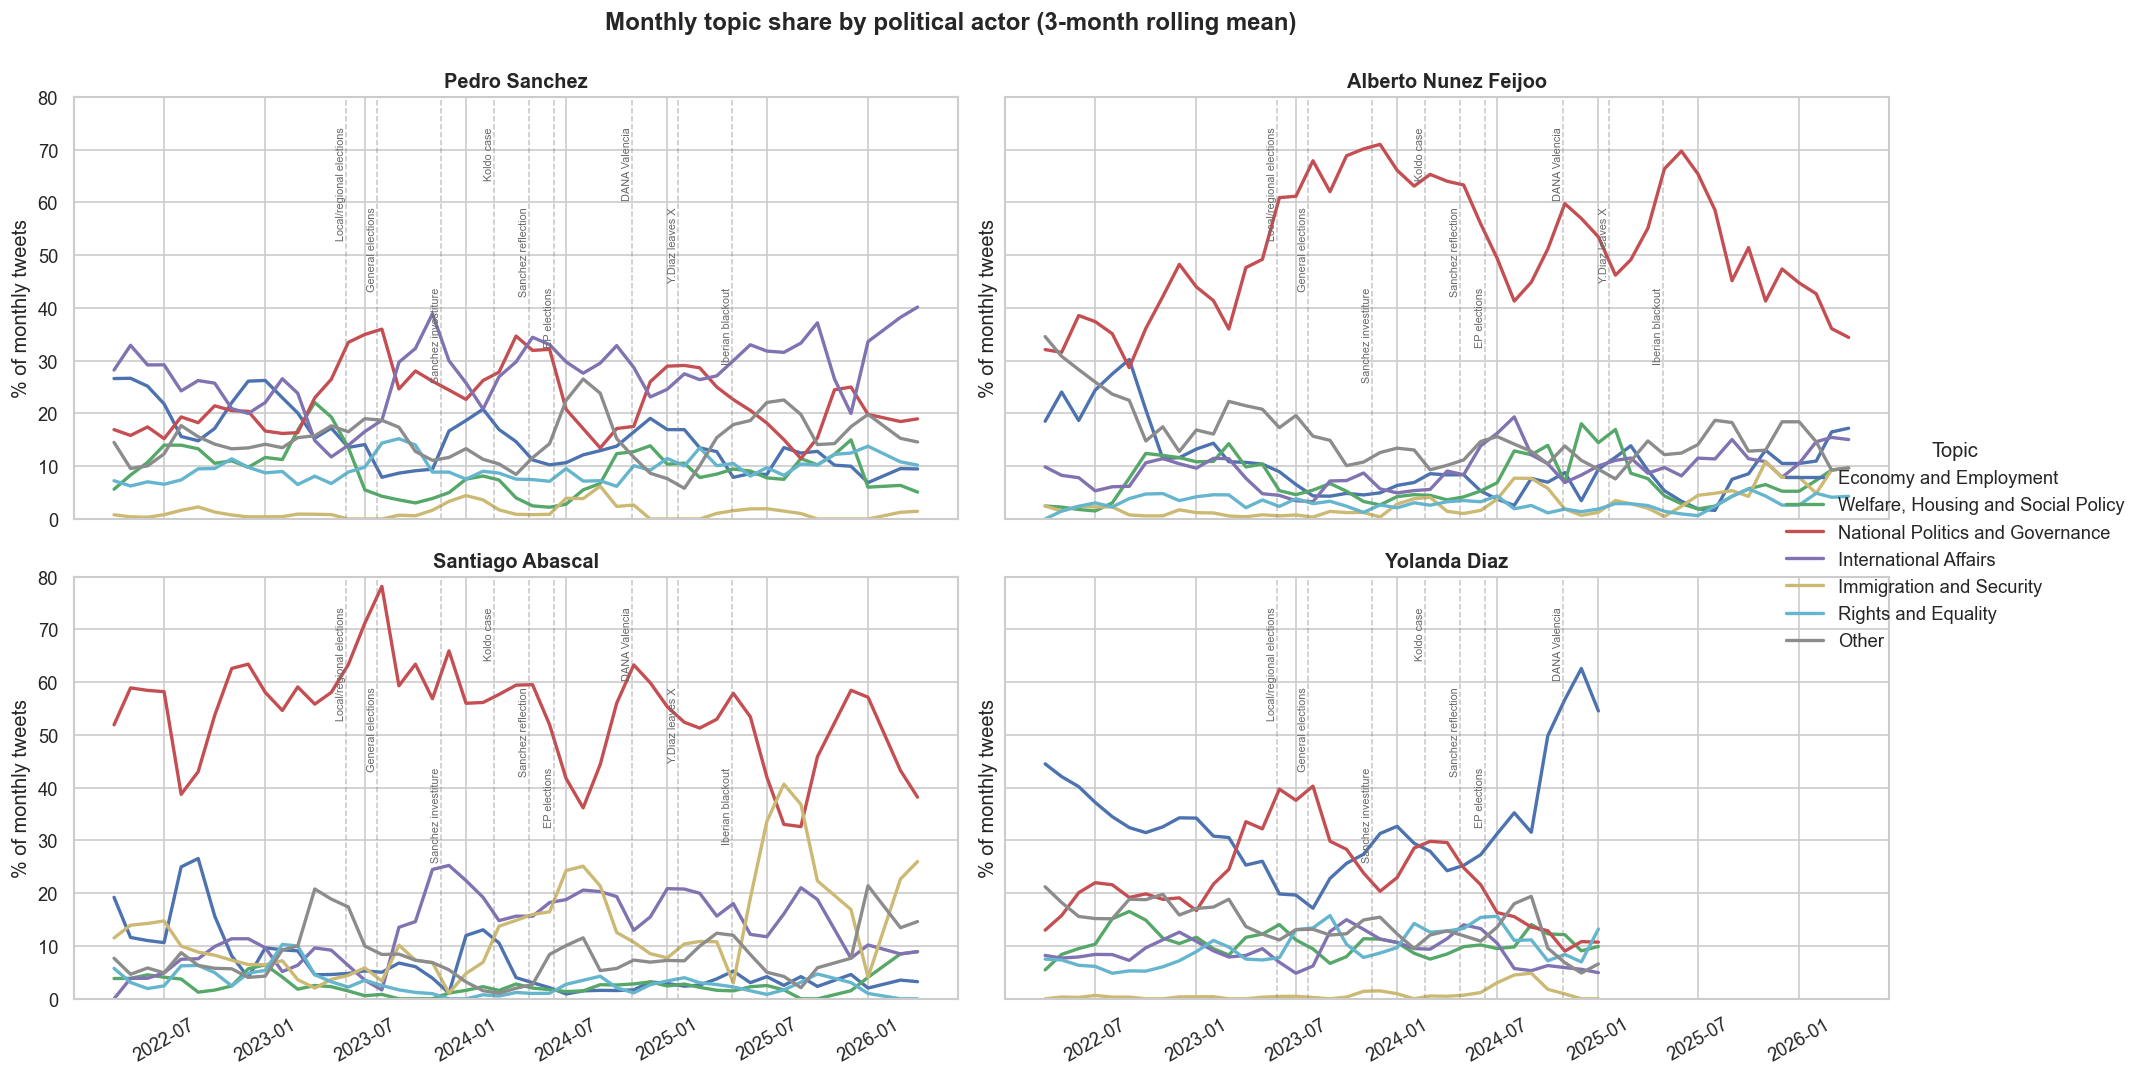

In [30]:
def monthly_topic_counts(df, politician):
    sub = df[df['politician'] == politician]
    cross = pd.crosstab(sub['month'], sub['topic'])
    return cross.reindex(columns=TOPIC_LABELS, fill_value=0)

def smoothed_topic_share(df, politician, window=3):
    counts = monthly_topic_counts(df, politician)
    sm = counts.rolling(window=window, center=True, min_periods=1).mean()
    return sm.div(sm.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

_event_levels = [0.93, 0.74, 0.55]

for ax, pol in zip(axes, POLITICIAN_ORDER):
    share = smoothed_topic_share(df, pol)
    for topic in TOPIC_LABELS:
        ax.plot(share.index, share[topic],
                label=topic, color=TOPIC_COLORS[topic], linewidth=2)
    # --- key-event annotation ---
    for j, (d, lbl) in enumerate(KEY_EVENTS.items()):
        d_ts = pd.Timestamp(d)
        if share.index.min() <= d_ts <= share.index.max():
            ax.axvline(d_ts, color='grey', linestyle='--', alpha=0.45, linewidth=0.9)
            ax.text(d_ts, 80 * _event_levels[j % len(_event_levels)], lbl,
                    rotation=90, va='top', ha='right', fontsize=6.5, color='dimgrey')
    ax.set_title(POLITICIAN_LABELS[pol], fontweight='bold')
    ax.set_ylabel('% of monthly tweets')
    ax.set_ylim(0, 80)
    ax.tick_params(axis='x', rotation=30)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5),
           title='Topic', frameon=False)
fig.suptitle('Monthly topic share by political actor (3-month rolling mean)',
             fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Pre-compute per-actor smoothed shares (reused in §7.7 and §7.8)
_shares = {pol: smoothed_topic_share(df, pol) for pol in POLITICIAN_ORDER}


The figure reveals clear differences in
the temporal structure of political communication across actors.
`National Politics and Governance` dominates the agenda of Pedro
Sanchez, Alberto Nunez Feijoo, and Santiago Abascal during most of the
corpus period, although with different levels of volatility and
reactivity.

Alberto Nunez Feijoo and Santiago Abascal display the strongest and most
persistent concentration around institutional and governance-related
topics, frequently exceeding 50% of their monthly communication. In the
case of Abascal, this dominance becomes particularly pronounced around
the 2023 electoral cycle and during later political controversies,
suggesting a highly reactive communication strategy centred on political
conflict.

Pedro Sanchez shows a comparatively more diversified agenda. Although
`National Politics and Governance` remains dominant, the trajectory of
`International Affairs` gains relevance during externally driven events,
while `Economy and Employment` and welfare-related topics maintain a
stable secondary presence throughout the period.

Yolanda Diaz exhibits the most differentiated thematic profile.
`Economy and Employment` clearly dominates her communication and
increases substantially during the final months before leaving the
platform in January 2025. Unlike the opposition actors, her agenda
places less emphasis on institutional conflict and maintains a more
policy-oriented structure focused on labour and welfare issues.

Several abrupt redistributions coincide with annotated political events,
particularly the 2023 general elections, the Sanchez investiture
process, the Amnesty Law debate, and the DANA crisis in Valencia. These
simultaneous fluctuations across actors suggest that major political
events strongly shape thematic attention across the Spanish political
communication ecosystem.

## Agenda composition over time (stacked areas)

The same per-actor series, displayed as a stacked area chart at 100 %.
Where the line plot above isolates each topic's trajectory, this view
exposes the *compositional* dynamics: how the agenda of each actor
redistributes between topics from month to month.

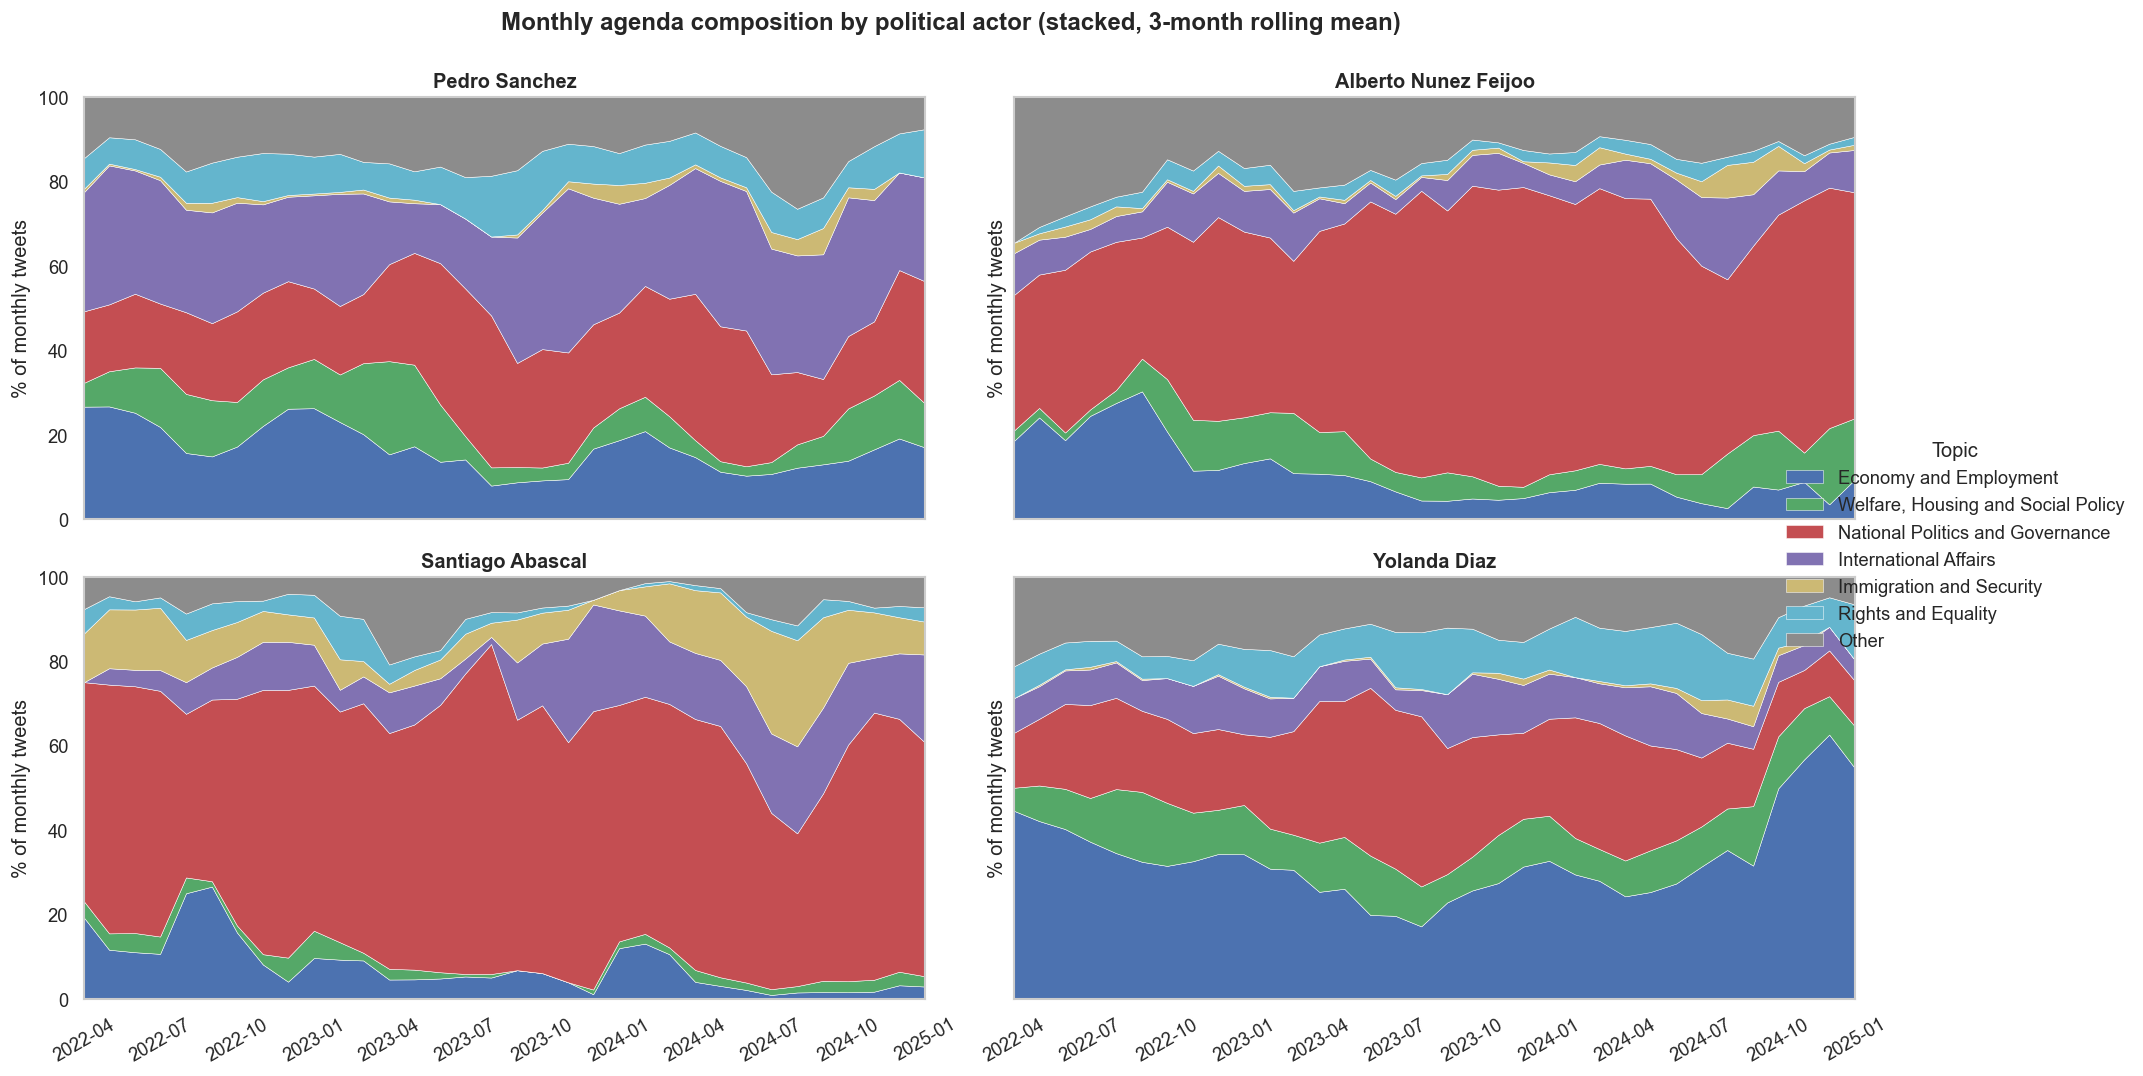

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, pol in zip(axes, POLITICIAN_ORDER):
    share = smoothed_topic_share(df, pol)
    ax.stackplot(share.index,
                 [share[t] for t in TOPIC_LABELS],
                 labels=TOPIC_LABELS,
                 colors=[TOPIC_COLORS[t] for t in TOPIC_LABELS],
                 edgecolor='white', linewidth=0.3)
    ax.set_title(POLITICIAN_LABELS[pol], fontweight='bold')
    ax.set_ylabel('% of monthly tweets')
    ax.set_ylim(0, 100)
    ax.set_xlim(share.index.min(), share.index.max())
    ax.tick_params(axis='x', rotation=30)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5),
           title='Topic', frameon=False)
fig.suptitle('Monthly agenda composition by political actor '
             '(stacked, 3-month rolling mean)',
             fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

The stacked area plots show how each actor's
monthly agenda is internally distributed across topics. This view
confirms that `National Politics and Governance` is the main component
of the agenda for Alberto Nunez Feijoo and Santiago Abascal, while Pedro
Sanchez and Yolanda Diaz present more diversified profiles.

Alberto Nunez Feijoo shows the most concentrated agenda. From mid-2023
onwards, `National Politics and Governance` occupies a very large share
of his monthly communication, often close to or above half of the total.
This suggests a communication strategy strongly focused on institutional
conflict, parliamentary competition, and government-opposition dynamics.

Santiago Abascal also presents a highly concentrated agenda, with
`National Politics and Governance` dominating most of the period. However,
his composition becomes more variable during 2024 and 2025, when topics
such as `International Affairs` and especially `Immigration and Security`
gain temporary weight. This indicates a more reactive agenda, where
specific events can quickly alter the thematic balance.

Pedro Sanchez displays a more balanced agenda. Although institutional
politics remains important, `International Affairs`, `Economy and
Employment`, and `Other` keep a visible presence across the period. This
is consistent with a government profile that combines domestic political
communication with international and policy-related issues.

Yolanda Diaz has the most clearly differentiated composition. Her agenda
is dominated by `Economy and Employment`, especially in the final months
before leaving X in January 2025. Welfare and social-policy topics also
remain relevant, while `National Politics and Governance` occupies a
smaller and less dominant role than in the opposition actors.

It is seen the figure shows two different agenda structures: a more
conflict-centred agenda among Feijoo and Abascal, and a more
policy-oriented or diversified agenda among Sanchez and Diaz. It also
shows that major political periods tend to increase agenda concentration,
with actors temporarily focusing their communication on fewer dominant
topics.

## Topic-by-topic comparison across actors

The inverse view: each panel fixes a topic and overlays the four
actors. Reading is by topic — which actor leads each agenda dimension
at each moment of the corpus, and where actors converge or diverge on a
given issue.

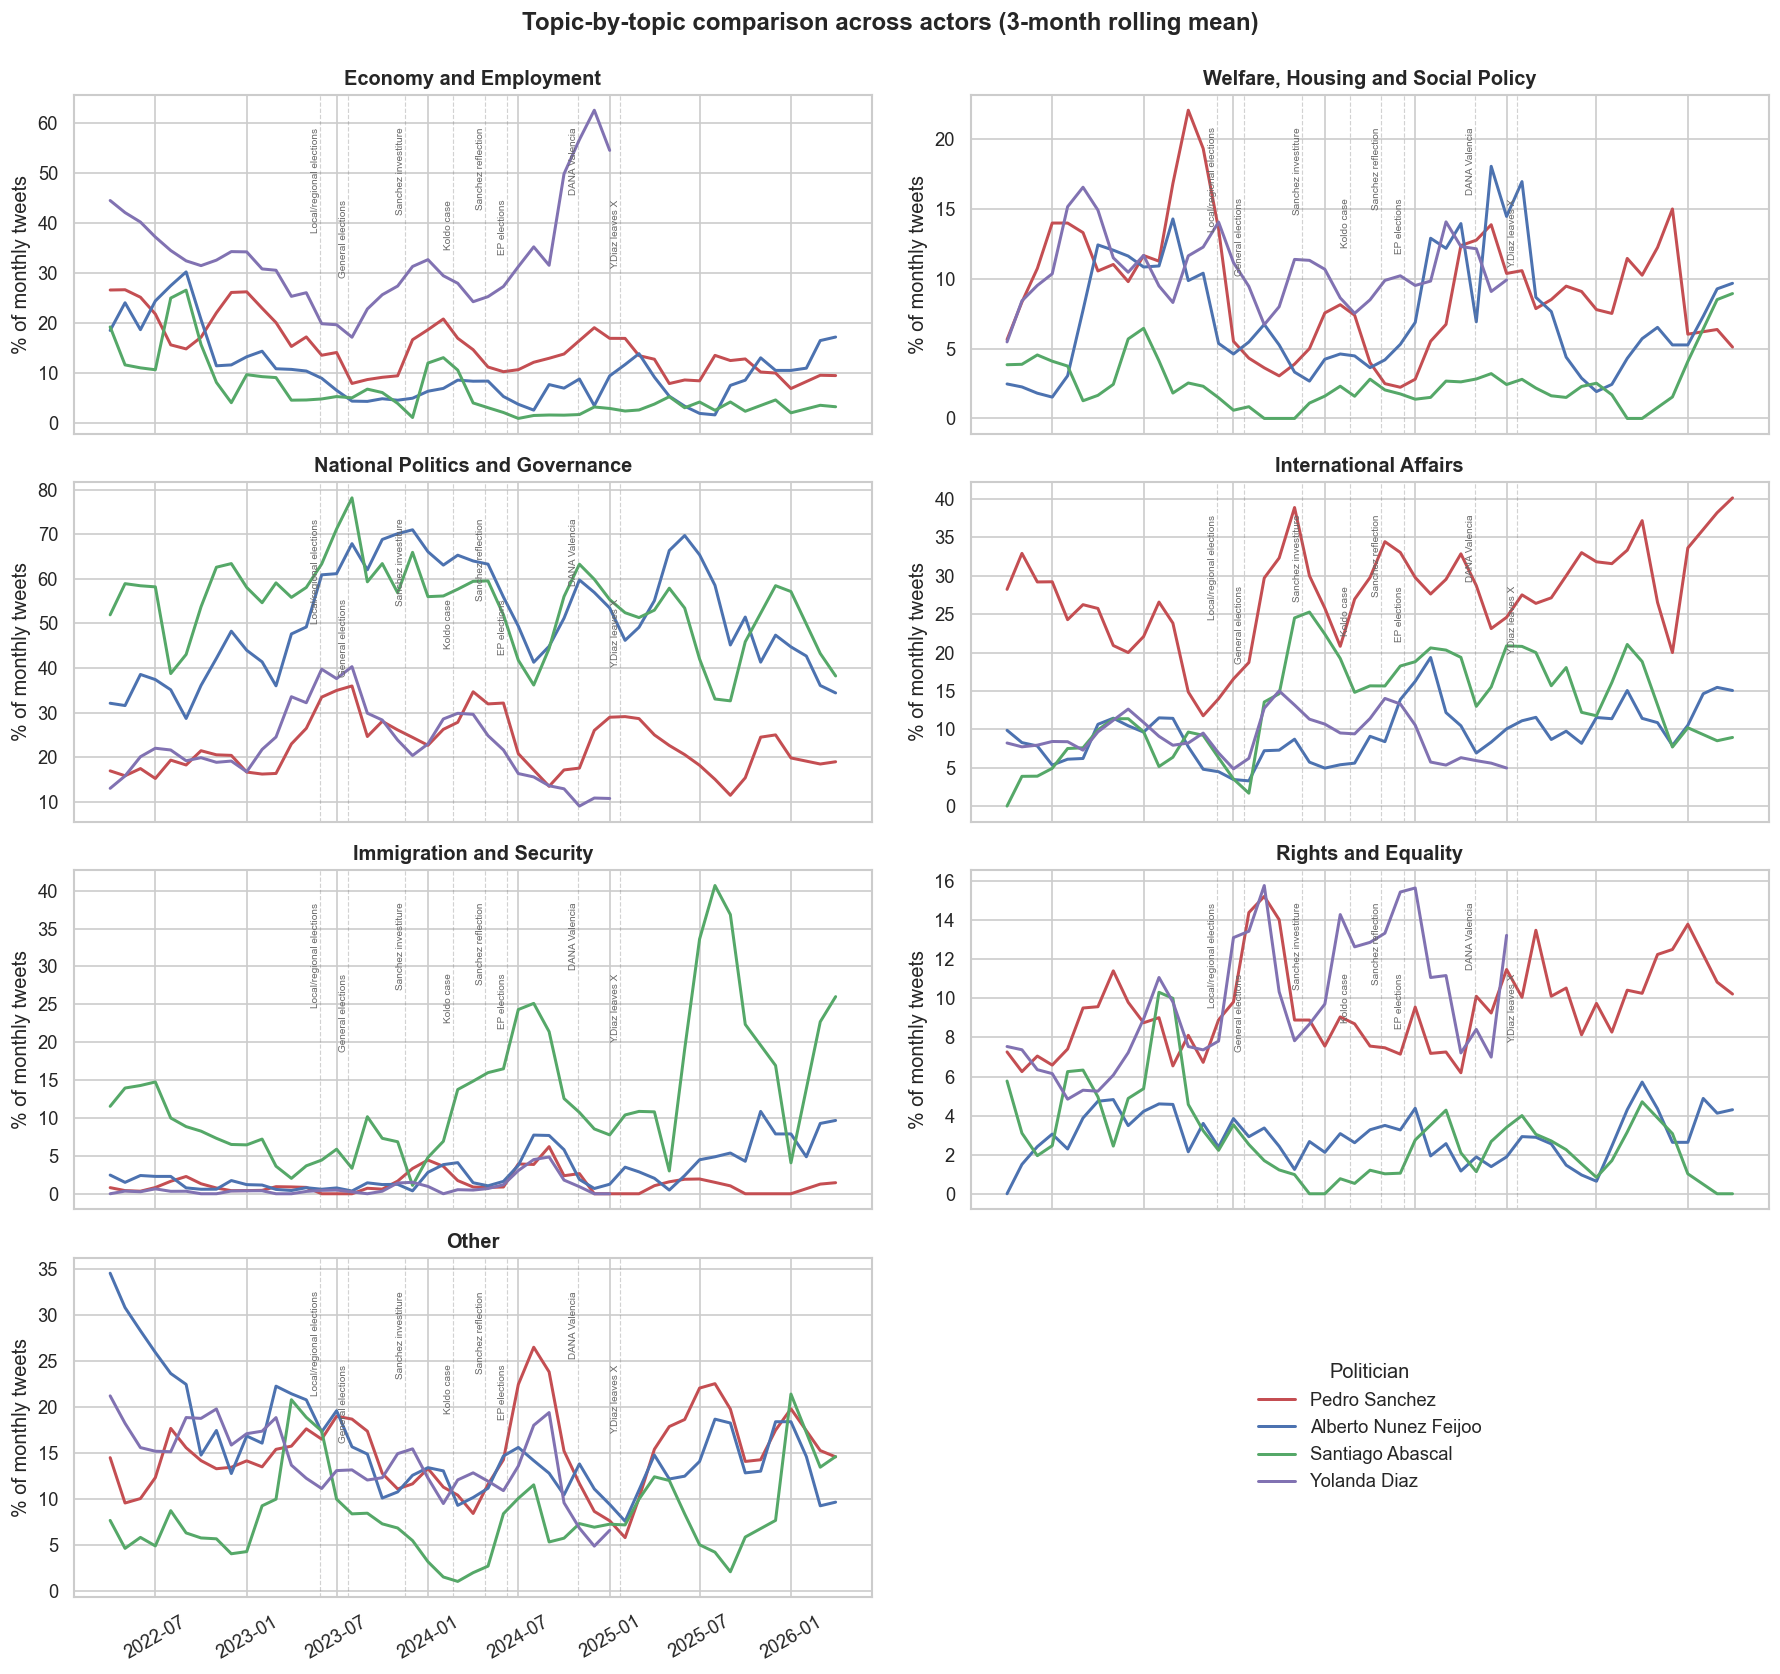

In [25]:
fig, axes = plt.subplots(4, 2, figsize=(15, 14), sharex=True)
axes = axes.flatten()

_event_levels_tt = [0.90, 0.68]

for i, topic in enumerate(TOPIC_LABELS):
    ax = axes[i]
    for pol in POLITICIAN_ORDER:
        share = smoothed_topic_share(df, pol)
        ax.plot(share.index, share[topic],
                label=POLITICIAN_LABELS[pol],
                color=POLITICIAN_COLORS[pol], linewidth=1.8)
    # --- key-event annotation ---
    y_top = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 60
    for j, (d, lbl) in enumerate(KEY_EVENTS.items()):
        d_ts = pd.Timestamp(d)
        ax.axvline(d_ts, color='grey', linestyle='--', alpha=0.35, linewidth=0.7)
        ax.text(d_ts, y_top * _event_levels_tt[j % 2], lbl,
                rotation=90, va='top', ha='right', fontsize=6, color='dimgrey')
    ax.set_title(topic, fontweight='bold')
    ax.set_ylabel('% of monthly tweets')
    ax.tick_params(axis='x', rotation=30)

axes[-1].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc='center', title='Politician',
                frameon=False, fontsize=11)
fig.suptitle('Topic-by-topic comparison across actors '
             '(3-month rolling mean)',
             fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


This figure compares the four actors
within each topic, making it possible to identify issue ownership,
convergence, and divergence over time. The results show that each topic
has a different political structure: some themes are shared by several
actors, while others are clearly associated with one specific profile.

`Economy and Employment` is mainly associated with Yolanda Diaz, whose
share remains above the other actors for most of the period and increases
sharply in the final months before she leaves X. This is consistent with
her institutional role and with a communication style focused on labour
and employment policy. Pedro Sanchez also gives some attention to this
topic, but with a lower and more stable intensity.

`National Politics and Governance` is the most central topic for the
whole political system, but it is especially dominant among Santiago
Abascal and Alberto Nunez Feijoo. Both actors frequently remain above
50% of their monthly communication in this category, particularly around
the 2023 electoral cycle and later institutional conflicts. Pedro
Sanchez and Yolanda Diaz show lower levels, which suggests a less
conflict-centred agenda.

`International Affairs` is led by Pedro Sanchez throughout most of the
corpus. His trajectory remains clearly above the rest of the actors,
especially during periods linked to international events and government
activity. Santiago Abascal also shows some increases in this topic,
while Feijoo and Diaz generally remain at lower levels.

`Immigration and Security` is the clearest case of issue ownership.
Santiago Abascal dominates this topic by a large margin, with several
sharp peaks in 2024 and 2025. The other actors remain close to zero or
only show small temporary increases. This confirms that immigration and
security are highly distinctive elements of Abascal's agenda.

`Rights and Equality` is more strongly associated with Pedro Sanchez and
Yolanda Diaz, although the latter stops contributing after January 2025.
The topic remains relatively marginal for Feijoo and Abascal. Finally,
the `Other` category is more evenly distributed and fluctuates across
actors, suggesting that it captures heterogeneous content rather than a
stable political agenda.



## Structural-break detection

To move beyond visual inspection, the monthly share of three politically
reactive topics (*National Politics and Governance*, *Economy and Employment*,
and *Immigration and Security*) is submitted to a structural-break analysis
using the Binseg algorithm with an rbf kernel (`ruptures` library).
The algorithm minimises the sum of kernel costs within segments and detects
up to two break points per series.



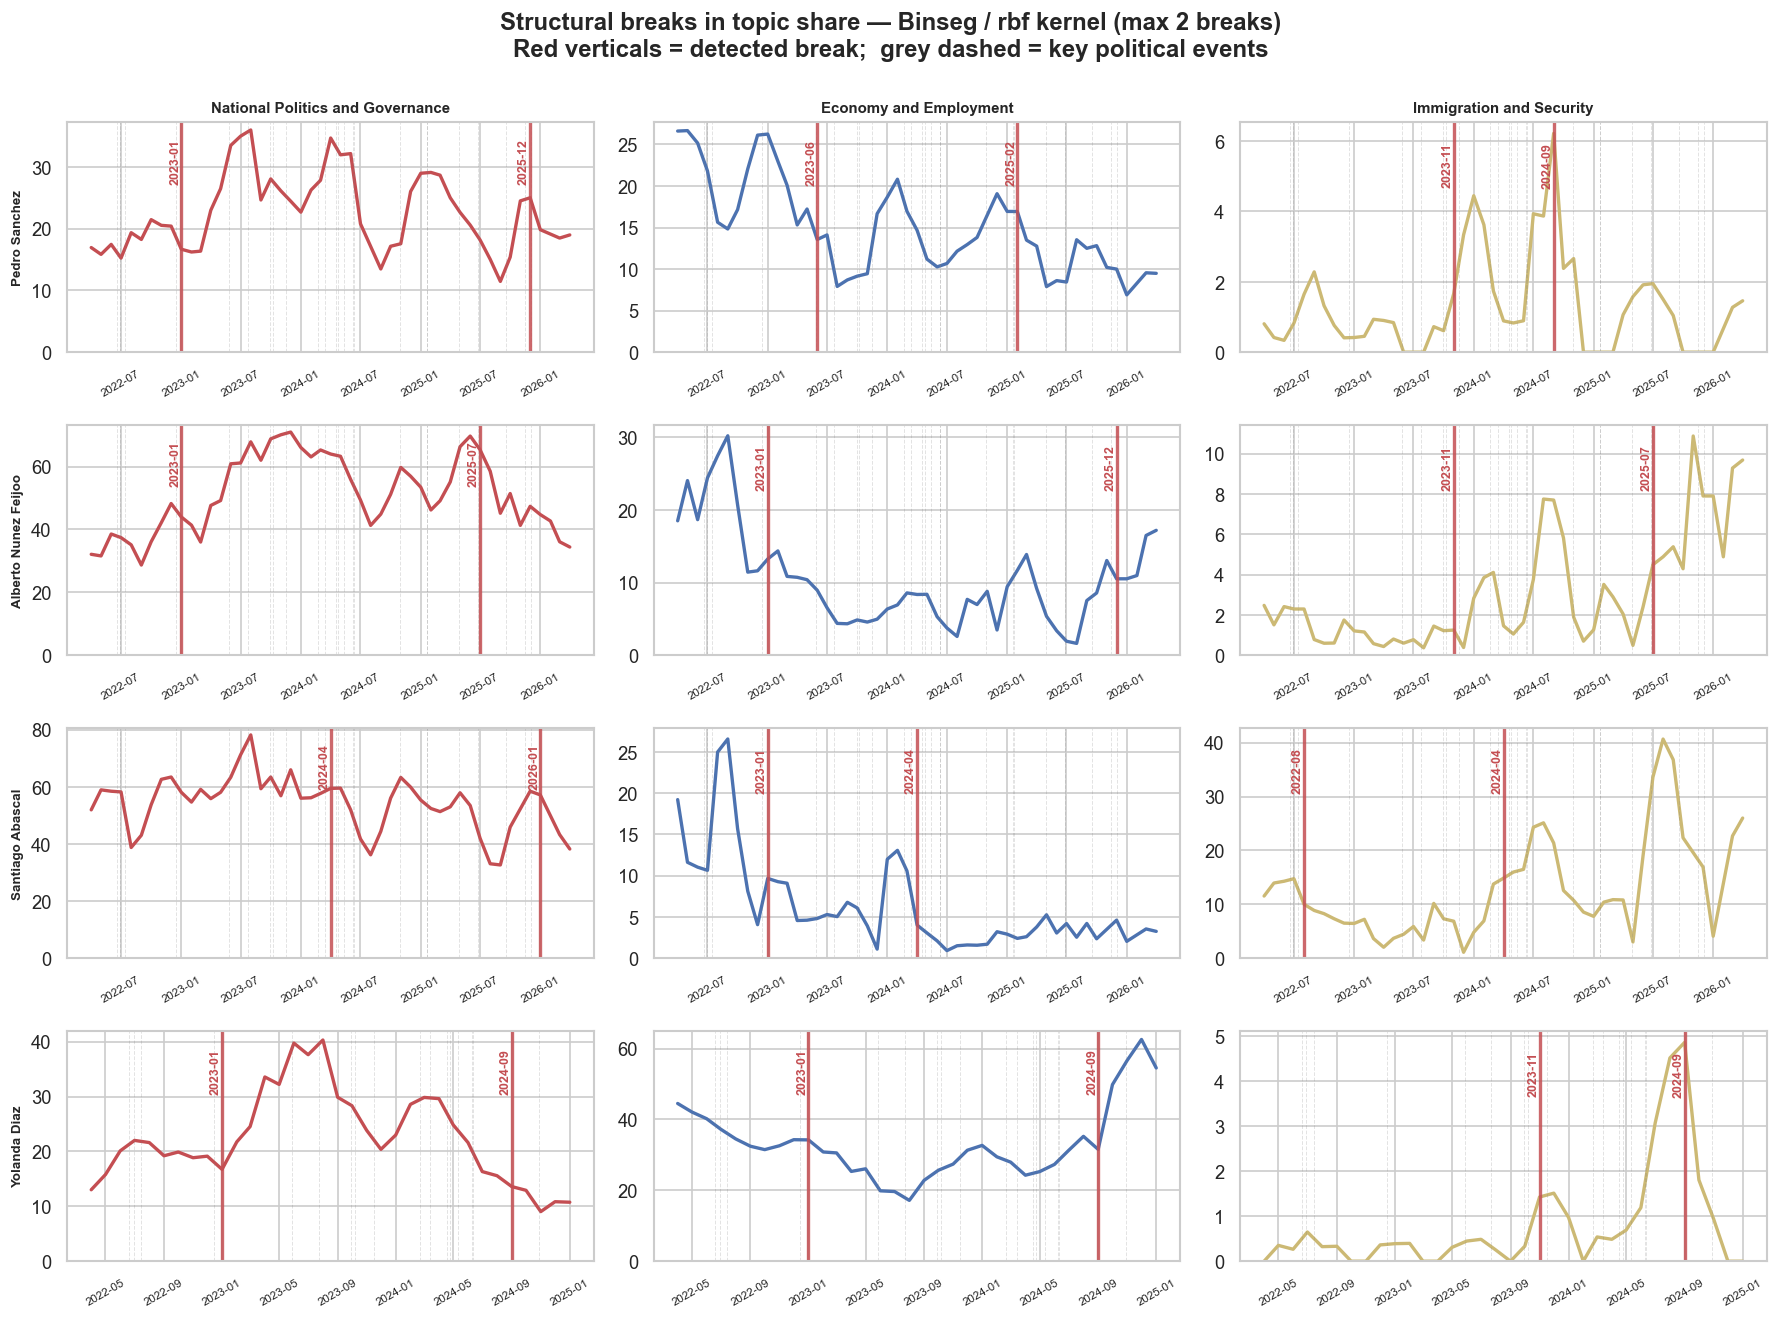

In [37]:
import ruptures as rpt

BREAK_TOPICS = [
    'National Politics and Governance',
    'Economy and Employment',
    'Immigration and Security',
]
N_BKPS = 2   # max break-points per series

fig, axes = plt.subplots(len(POLITICIAN_ORDER), len(BREAK_TOPICS),
                          figsize=(15, 11), sharex=False)

for row, pol in enumerate(POLITICIAN_ORDER):
    share = _shares[pol]
    for col, topic in enumerate(BREAK_TOPICS):
        ax = axes[row, col]
        series = share[topic].values
        dates  = share.index

        ax.plot(dates, series, color=TOPIC_COLORS[topic], linewidth=2)

        # grey event lines (full catalogue)
        for d in EVENTS:
            d_ts = pd.Timestamp(d)
            if dates.min() <= d_ts <= dates.max():
                ax.axvline(d_ts, color='grey', linestyle='--',
                           alpha=0.22, linewidth=0.6)

        # structural breaks
        algo = rpt.Binseg(model='rbf').fit(series)
        bkps = algo.predict(n_bkps=N_BKPS)
        y_top = series.max() if series.max() > 0 else 1
        for bkp in bkps[:-1]:
            if 0 < bkp < len(dates):
                bkp_date = dates[bkp - 1]
                ax.axvline(bkp_date, color='#C44E52', linestyle='-',
                           linewidth=2, alpha=0.85)
                ax.text(bkp_date, y_top * 0.96,
                        bkp_date.strftime('%Y-%m'),
                        rotation=90, va='top', ha='right',
                        fontsize=7.5, color='#C44E52', fontweight='bold')

        if row == 0:
            ax.set_title(topic, fontweight='bold', fontsize=9)
        if col == 0:
            ax.set_ylabel(POLITICIAN_LABELS[pol], fontweight='bold', fontsize=8)
        ax.set_ylim(bottom=0)
        ax.tick_params(axis='x', rotation=30, labelsize=7)

fig.suptitle(
    f'Structural breaks in topic share — Binseg / rbf kernel (max {N_BKPS} breaks)\n'
    'Red verticals = detected break;  grey dashed = key political events',
    fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()


The structural-break analysis shows
that the main temporal discontinuities are not evenly distributed across
actors or topics. Most detected breaks appear in `National Politics and
Governance` and `Economy and Employment`, while `Immigration and
Security` presents fewer but more actor-specific shifts.

For Pedro Sanchez, the detected breaks suggest two main phases in
institutional communication: an initial period of moderate fluctuation,
followed by a redistribution around early 2023 and another change near
the end of 2025. In `Economy and Employment`, the breaks around mid-2023
and late 2024 indicate changes in the relative weight of economic and
labour-related communication. His `Immigration and Security` series
remains low overall, although isolated peaks appear around late 2023 and
2024.

Alberto Nunez Feijoo shows clear breaks in `National Politics and
Governance`, especially around early 2023 and mid-2025. These changes
coincide with periods of high political competition and institutional
conflict. In `Economy and Employment`, the detected breaks reflect a
transition from relatively high early attention to a lower and more
stable phase, followed by a later recovery. His `Immigration and
Security` series increases more clearly after 2024, with a detected
break in 2025.

Santiago Abascal presents the most distinctive pattern in
`Immigration and Security`. The break dates indicate a shift from a
moderate baseline to a much more prominent use of this topic during 2024
and 2025. This confirms that immigration and security are not only a
high-salience topic in his agenda, but also a highly dynamic one. His
`National Politics and Governance` series remains dominant throughout
the period, although the breaks indicate changes in intensity rather
than a complete thematic reorientation.

Yolanda Diaz displays a different structure. Her most relevant breaks
appear in `Economy and Employment`, with a strong increase in the final
months before leaving X in January 2025. In contrast, her
`Immigration and Security` trajectory remains close to zero for most of
the period, confirming that this topic is marginal in her communication.
Her `National Politics and Governance` breaks suggest temporary
redistributions, but not the same level of conflict-centred dominance
observed among Feijoo and Abascal.

This study the results support the idea that temporal topic evolution is
shaped by both shared political shocks and actor-specific agenda
strategies. Some breaks align with major political events, such as the
2023 electoral cycle, the investiture period, the Amnesty Law debate, and
the DANA crisis, while others reflect more gradual changes in each
actor's communication priorities.

## Cross-correlation and lead-lag between actors

The cross-correlation function measures whether the topic share of one actor
predicts another's with a lead or a lag. For each pair of actors and each
topic, the lag that maximises the absolute Pearson correlation is identified
in the window −4 … +4 months over the common period (Apr 2022 – Jan 2025).

The left panel reports the maximum correlation; the right panel the
corresponding lag (positive = first actor leads). Series with fewer than
five overlapping observations are excluded.

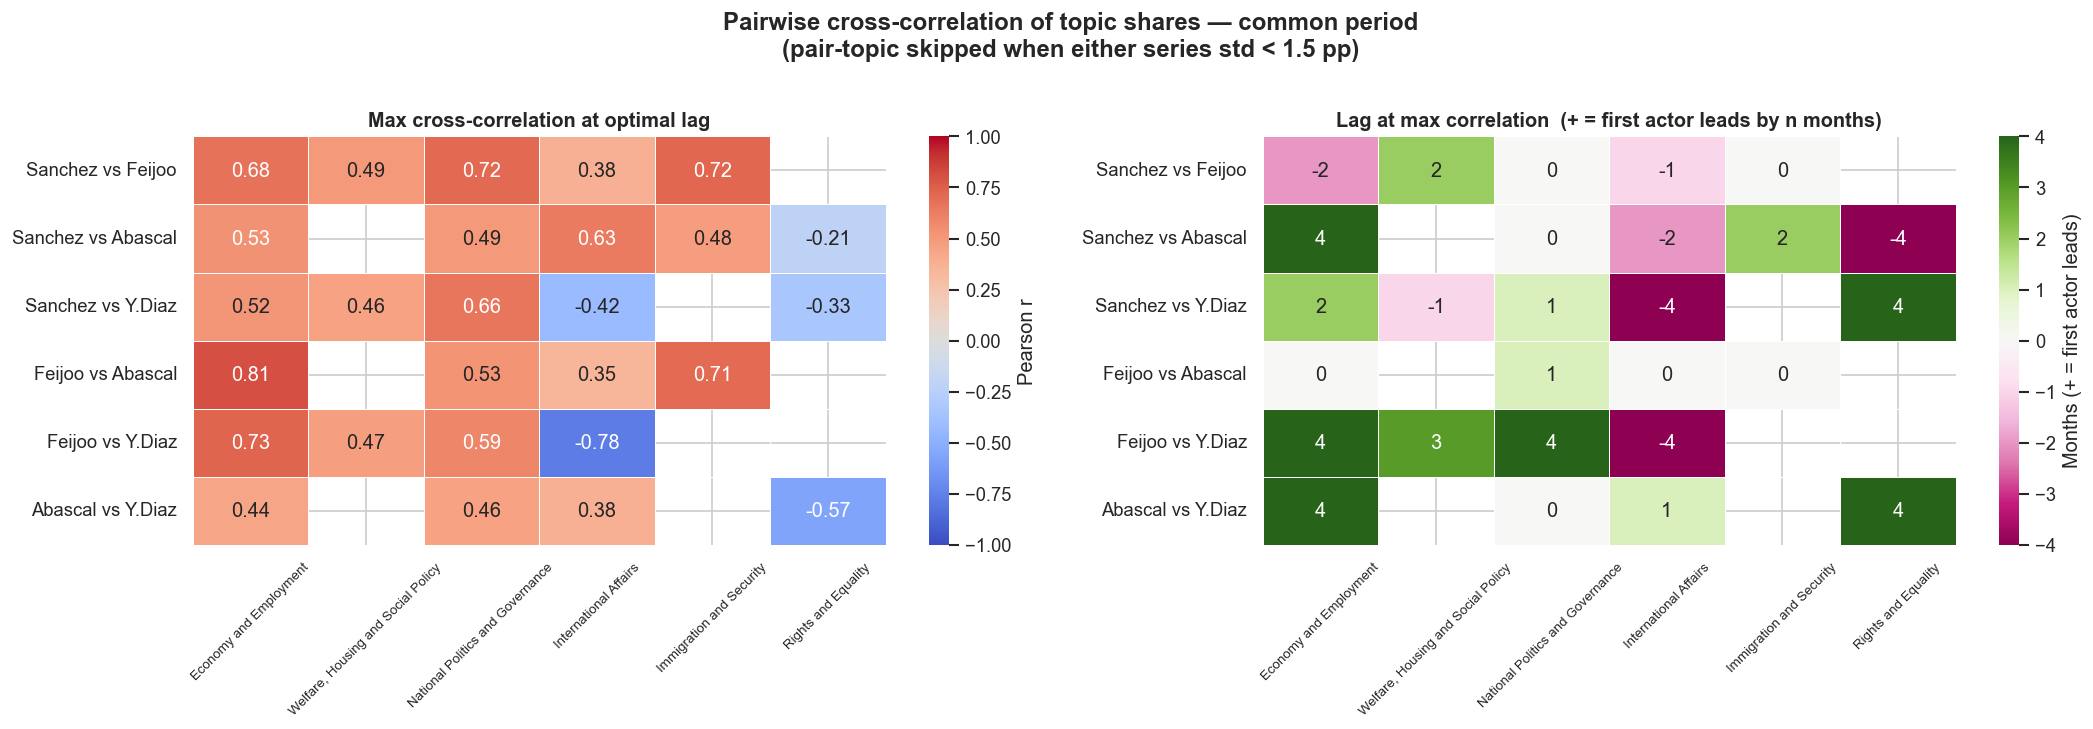

In [31]:
from scipy.stats import pearsonr

CORR_TOPICS = [t for t in TOPIC_LABELS if t != 'Other']
LAGS        = list(range(-4, 5))
MIN_STD     = 1.5   # percentage points; pair-topic skipped if either series is flatter than this

pairs       = [(POLITICIAN_ORDER[i], POLITICIAN_ORDER[j])
               for i in range(len(POLITICIAN_ORDER))
               for j in range(i + 1, len(POLITICIAN_ORDER))]
pair_labels = [f'{SHORT_LABELS[a]} vs {SHORT_LABELS[b]}' for a, b in pairs]


def xcorr_lag(pol_a, pol_b, topic, lag):
    sa = _shares[pol_a][topic]
    sb = _shares[pol_b][topic]
    idx = sa.index.intersection(sb.index)
    idx = idx[(idx >= COMMON_START) & (idx <= COMMON_END)]
    a, b = sa.loc[idx].values, sb.loc[idx].values

    # Variance gate: a near-constant series (e.g. Immigration for Yolanda Diaz)
    # produces spurious correlations driven by noise. Skip if either side is flat.
    if np.std(a) < MIN_STD or np.std(b) < MIN_STD:
        return np.nan

    if lag > 0:
        a, b = a[lag:], b[:-lag]
    elif lag < 0:
        a, b = a[:lag], b[-lag:]
    if len(a) < 5:
        return np.nan
    r, _ = pearsonr(a, b)
    return r


rmax_matrix = pd.DataFrame(index=pair_labels, columns=CORR_TOPICS, dtype=float)
lag_matrix  = pd.DataFrame(index=pair_labels, columns=CORR_TOPICS, dtype=float)

for (pol_a, pol_b), lbl in zip(pairs, pair_labels):
    for topic in CORR_TOPICS:
        corrs = [xcorr_lag(pol_a, pol_b, topic, lag) for lag in LAGS]
        valid = [(l, c) for l, c in zip(LAGS, corrs) if not np.isnan(c)]
        if not valid:
            continue
        best_lag, best_r = max(valid, key=lambda x: abs(x[1]))
        rmax_matrix.loc[lbl, topic] = best_r
        lag_matrix.loc[lbl, topic]  = best_lag

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(rmax_matrix.astype(float), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            ax=axes[0], cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Max cross-correlation at optimal lag', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(lag_matrix.astype(float), annot=True, fmt='.0f',
            cmap='PiYG', center=0, vmin=-4, vmax=4,
            linewidths=0.5, linecolor='white',
            ax=axes[1], cbar_kws={'label': 'Months (+ = first actor leads)'})
axes[1].set_title('Lag at max correlation  (+ = first actor leads by n months)',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0)

fig.suptitle('Pairwise cross-correlation of topic shares — common period\n'
             f'(pair-topic skipped when either series std < {MIN_STD} pp)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The cross-correlation analysis shows
that several topic trajectories are synchronised across actors during
the common observation period. To avoid unstable results, pair-topic
combinations with almost flat series were excluded from the analysis.
Blank cells therefore indicate cases where at least one actor showed
very little temporal variation in that topic.

The strongest positive correlations appear in `Economy and Employment`,
`National Politics and Governance`, and `Immigration and Security`.
The highest synchrony is observed between Alberto Nunez Feijoo and
Santiago Abascal in `Economy and Employment` (r = 0.81), followed by
Sanchez and Feijoo in `National Politics and Governance` and
`Immigration and Security` (both r = 0.72). These values suggest that
several actors respond to shared political cycles and external events,
even when their ideological positions differ.

The matrix also reveals negative correlations in some topics. The
clearest case appears in `International Affairs` between Feijoo and
Yolanda Diaz (r = -0.78), suggesting opposite temporal patterns in this
area. Negative correlations are also observed in `Rights and Equality`,
especially for pairs involving Yolanda Diaz, which indicates that this
topic follows different temporal dynamics across actors.

The lag matrix provides an exploratory view of temporal ordering.
Several correlations in `National Politics and Governance` occur at or
near zero lag, meaning that actors often react within the same monthly
window to the same political context. Other topics show larger positive
or negative lags, suggesting more asymmetric agenda diffusion.

The results point to a mixed temporal structure. Some topics are
synchronised across the political system, especially institutional and
security-related issues, while others show clearer actor-specific timing.
The variance filter makes the interpretation more conservative by
excluding low-variation series where correlations would be unreliable.

(Blank cells indicate pair-topic combinations excluded from the analysis
because at least one of the two time series had very low temporal
variation (standard deviation below 1.5 percentage points). This filter
prevents spurious correlations driven by almost flat series, especially
in low-frequency topics.)

## Granger causality between actors

Granger causality tests whether past values of actor A's topic share
improve the prediction of actor B's topic share beyond B's own previous
values. In this section, the test is applied to raw monthly topic shares,
not to the smoothed series used in the descriptive figures, because
rolling averages introduce autocorrelation by construction.

To make the analysis more conservative, actor-topic pairs with very low
temporal variation are excluded, and p-values are adjusted using the
Benjamini-Hochberg false discovery rate correction. Empty cells indicate
relationships removed by the variance filter.


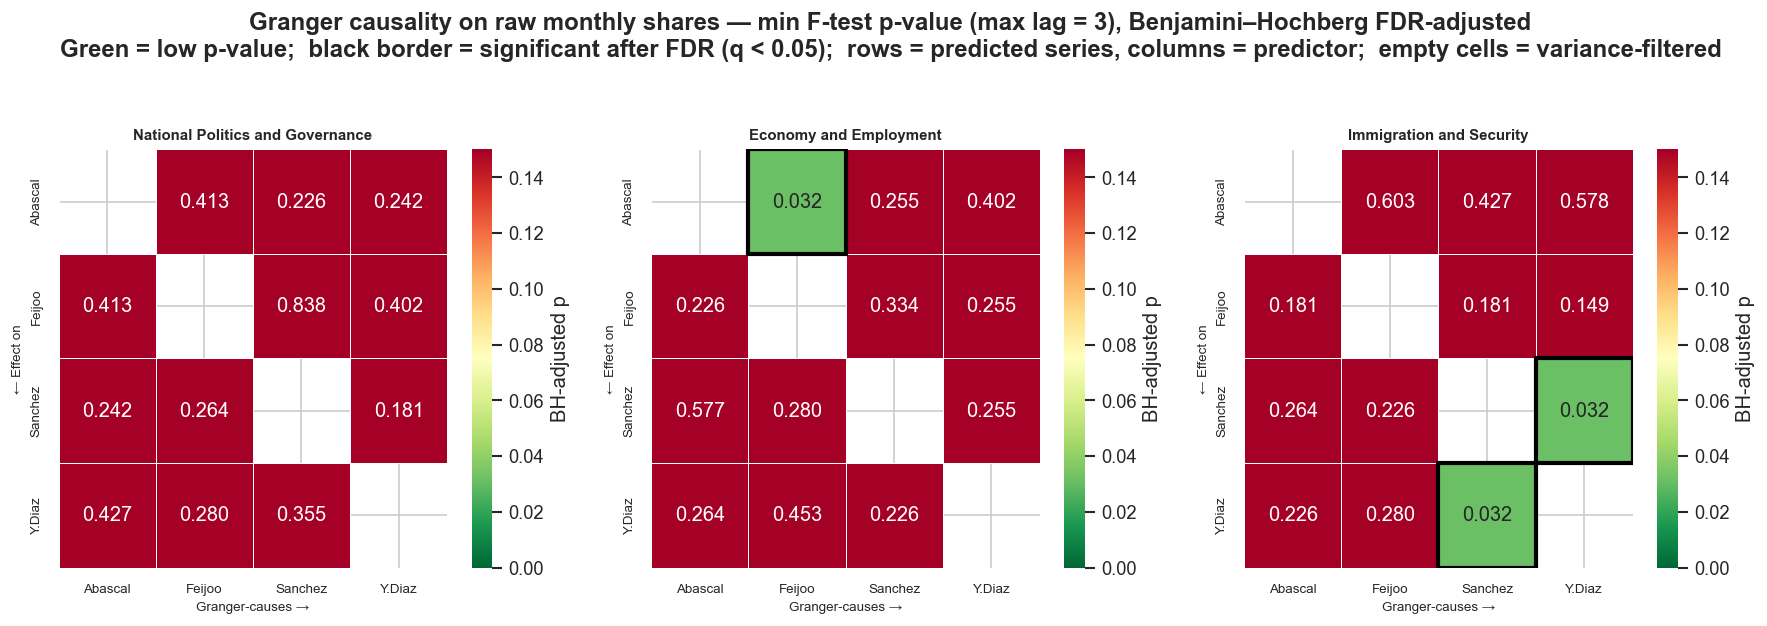

Granger links significant after BH-FDR correction (q < 0.05):
                   topic   cause  effect  min_p   p_bh
  Economy and Employment  Feijoo Abascal 0.0026 0.0316
Immigration and Security Sanchez  Y.Diaz 0.0024 0.0316
Immigration and Security  Y.Diaz Sanchez 0.0015 0.0316


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.multitest import multipletests
import warnings

GRANGER_TOPICS = [
    'National Politics and Governance',
    'Economy and Employment',
    'Immigration and Security',
]
MAX_LAG         = 3
MIN_STD_GRANGER = 1.5   



def monthly_topic_share_raw(df, politician):
    counts = monthly_topic_counts(df, politician)
    return counts.div(counts.sum(axis=1), axis=0) * 100

_shares_raw = {pol: monthly_topic_share_raw(df, pol) for pol in POLITICIAN_ORDER}

records = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for topic in GRANGER_TOPICS:
        for pol_a in POLITICIAN_ORDER:          # potential cause
            for pol_b in POLITICIAN_ORDER:      # effect series
                if pol_a == pol_b:
                    continue
                sa = _shares_raw[pol_a][topic]
                sb = _shares_raw[pol_b][topic]
                idx = sa.index.intersection(sb.index)
                idx = idx[(idx >= COMMON_START) & (idx <= COMMON_END)]
                idx = idx[sa.loc[idx].notna() & sb.loc[idx].notna()]
                if len(idx) < MAX_LAG + 5:
                    continue
                a = sa.loc[idx].values
                b = sb.loc[idx].values

                # Variance gate: skip near-constant series. The Granger F-test
                # can still return small p-values when a series is essentially
                # noise around a flat baseline; those rejections are not
                # substantive findings.
                if np.std(a) < MIN_STD_GRANGER or np.std(b) < MIN_STD_GRANGER:
                    continue

                data = np.column_stack([b, a])
                try:
                    res = grangercausalitytests(data, maxlag=MAX_LAG, verbose=False)
                    min_p = min(res[lag][0]['ssr_ftest'][1]
                                for lag in range(1, MAX_LAG + 1))
                    records.append({
                        'topic':  topic,
                        'cause':  SHORT_LABELS[pol_a],
                        'effect': SHORT_LABELS[pol_b],
                        'min_p':  min_p,
                    })
                except Exception:
                    pass

granger_df = pd.DataFrame(records)

# --- Benjamini–Hochberg FDR correction over the full set of tests ---
if len(granger_df) > 0:
    rejected, p_adj, _, _ = multipletests(granger_df['min_p'].values,
                                          alpha=0.05, method='fdr_bh')
    granger_df['p_bh']      = p_adj
    granger_df['sig_bh']    = rejected
    granger_df['min_p']     = granger_df['min_p'].round(4)
    granger_df['p_bh']      = granger_df['p_bh'].round(4)

fig, axes = plt.subplots(1, len(GRANGER_TOPICS), figsize=(15, 5))
for i, topic in enumerate(GRANGER_TOPICS):
    sub      = granger_df[granger_df['topic'] == topic]
    pivot_p  = sub.pivot(index='effect', columns='cause', values='p_bh')
    pivot_s  = sub.pivot(index='effect', columns='cause', values='sig_bh')

    sns.heatmap(pivot_p.astype(float), annot=True, fmt='.3f',
                cmap='RdYlGn_r', vmin=0, vmax=0.15,
                linewidths=0.5, linecolor='white', ax=axes[i],
                cbar_kws={'label': 'BH-adjusted p'})

    for r_idx in range(len(pivot_s.index)):
        for c_idx in range(len(pivot_s.columns)):
            val = pivot_s.iloc[r_idx, c_idx]
            if pd.notna(val) and bool(val):
                axes[i].add_patch(plt.Rectangle(
                    (c_idx, r_idx), 1, 1,
                    fill=False, edgecolor='black', linewidth=2.5, zorder=5))

    axes[i].set_title(topic, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Granger-causes \u2192', fontsize=8)
    axes[i].set_ylabel('\u2190 Effect on', fontsize=8)
    axes[i].tick_params(labelsize=8)

fig.suptitle(
    f'Granger causality on raw monthly shares — min F-test p-value '
    f'(max lag = {MAX_LAG}), Benjamini–Hochberg FDR-adjusted\n'
    'Green = low p-value;  black border = significant after FDR (q < 0.05);  '
    'rows = predicted series, columns = predictor;  empty cells = variance-filtered',
    fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# Optional: show the surviving (FDR-significant) links as a table
if 'sig_bh' in granger_df.columns and granger_df['sig_bh'].any():
    print('Granger links significant after BH-FDR correction (q < 0.05):')
    print(granger_df[granger_df['sig_bh']]
            [['topic', 'cause', 'effect', 'min_p', 'p_bh']]
            .to_string(index=False))
else:
    print('No Granger links survive BH-FDR correction at q < 0.05.')

The Granger-causality analysis was run on
raw monthly topic shares rather than on the smoothed series used in the
descriptive plots. This decision avoids the artificial autocorrelation
introduced by the 3-month rolling mean and makes the inferential test
more conservative. In addition, actor-topic pairs with very low temporal
variation were excluded, and p-values were adjusted using the
Benjamini-Hochberg false discovery rate procedure.

After applying these restrictions, only a small number of relationships
remain statistically significant. In `Economy and Employment`, Alberto
Nunez Feijoo significantly Granger-predicts Santiago Abascal, suggesting
a delayed temporal association between the economic agenda of the two
opposition actors.

In `Immigration and Security`, two significant links appear between
Pedro Sanchez and Yolanda Diaz. This result should be interpreted with
particular caution, since this topic has relatively low salience for
government actors compared with Santiago Abascal. Rather than indicating
direct political influence, these links may reflect shared responses to
specific events or statistical sensitivity in low-volume topic series.

No significant Granger relationships survive the FDR correction in
`National Politics and Governance`. This is relevant because, although
this topic shows high descriptive synchrony in the previous section, the
Granger test does not provide strong evidence of directional predictive
influence once smoothing, low-variance series, and multiple testing are
controlled.

The results suggest that temporal dependencies between actors
exist only in a limited number of actor-topic combinations. The Granger
analysis therefore supports a cautious conclusion: political actors often
move in parallel around the same events, but this synchrony does not
necessarily imply robust directional influence between their agendas.

## Summary

Three findings emerge from the temporal analysis.

First, the four actors show clearly different levels of topic stability
and volatility. `National Politics and Governance` is the dominant topic
for Alberto Nunez Feijoo and Santiago Abascal, whose agendas are more
strongly centred on institutional conflict and political competition.
Pedro Sanchez presents a more diversified agenda, combining national
politics with international affairs, economy, and other policy-related
topics. Yolanda Diaz shows the most differentiated profile, with a
stable and increasing focus on `Economy and Employment`, especially in
the final months before leaving X in January 2025. `Immigration and
Security` is the most actor-specific topic, being clearly dominated by
Santiago Abascal and remaining marginal for the other actors.

Second, the figures show that major political events are associated with
visible agenda redistribution episodes. The 2023 electoral cycle, the
Sanchez investiture process, the Amnesty Law debate, the DANA crisis in
Valencia, and other institutional controversies coincide with shifts in
topic salience across several actors. The structural-break analysis
confirms that some of these changes are not only visually apparent, but
also correspond to detectable changes in the temporal series. This
suggests that topic evolution is shaped by both long-term political
positioning and short-term reactions to external events.

Third, the temporal behaviour reinforces the bloc and institutional
structure identified in previous steps. Government actors show more
policy-oriented and diversified trajectories, especially in economy,
employment, welfare, international affairs, and rights-related topics.
Opposition actors, particularly Feijoo and Abascal, concentrate more
strongly on `National Politics and Governance`, reflecting a more
conflict-centred communication strategy. At the same time, the
cross-correlation and Granger analyses show that actors do not evolve
independently: several topics, especially `Economy and Employment`,
`National Politics and Governance`, and `Immigration and Security`,
present synchronised or temporally connected movements between actors.

The temporal dynamics described above are the input to future work on
network structure and polarization, where the question shifts from
*what* each actor talks about over time to *with whom* their agenda
aligns at any given moment.